# Problem Defintion

Banks often need to check the credit score of people and they have to decide whether or not to give a person lone based on their Credit History and Loans they took earlier and if they were able to pay them off or not. So, I am required to build an Ml model to decide whether a person will default or not if given a loan by a bank based on their Credit History.

# Data Set

I will be using a dataset availaible on Kaggle as Give Me Some Credit on this specific link : https://www.kaggle.com/competitions/GiveMeSomeCredit/overview

# Data Explanation

The dataset consists of the Following Columns ⁉

* SeriousDlqin2yrs : Person experienced 90 days past due delinquency or worse.

Data Type - Y/N

* RevolvingUtilizationOfUnsecuredLine : Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits.

Data Type - Percentage

* Age : Age of borrower in years.

Data Type - integer

* NumberOfTime30-59DaysPastDueNotWorse : Number of times borrower has been 30-59 days past due but no worse in the last 2 years.

Data Type - integer

* DebtRatio : Monthly debt payments, alimony,living costs divided by monthy gross income.

Data Type - Percentage

* MonthlyIncome : Monthly Income

Data Type - real

* NumberOfOpenCreditLinesAndLoans : Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards).

Data Type - integer

* NumberOfTimes90DaysLate : Number of times borrower has been 90 days or more past due.

Data Type - integer

* NumberRealEstateLoansOrLines : Number of mortgage and real estate loans including home equity lines of credit

Data Type - integer

* NumberOfTime60-89DaysPastDueNotWorse : 89DaysPastDueNotWorse	Number of times borrower has been 60-89 days past due but no worse in the last 2 years.

Data Type - integer

* NumberOfDependents : Number of Dependents in the family excluding themselves (spouse, children etc.)

Data Type - integer

# Goal
The goal of building this model is to predict whether a person will default or not to prevent the bank's losses.


In [ ]:
# Importing all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


In [ ]:
# Importing Data
df = pd.read_csv("cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [ ]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
df.drop(columns=["Unnamed: 0"], inplace = True)

In [ ]:
(df.isna().sum()/len(df))*100

,0
SeriousDlqin2yrs,0.000000
RevolvingUtilizationOfUnsecuredLines,0.000000
age,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000
DebtRatio,0.000000
MonthlyIncome,19.820667
NumberOfOpenCreditLinesAndLoans,0.000000
NumberOfTimes90DaysLate,0.000000
NumberRealEstateLoansOrLines,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000


## Removal of Unnecessary Column and Adding Missing values

Here the Unnamed : 0 column was useless so I removed it and I found out that there were approx 20% columns of Monthly Income and Approx 3% columns for the Nummber of Dependents were empty 20% is huge so the best approach is to replace this NA values with the Median

In [ ]:
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(), inplace=True)

/tmp/ipykernel_654/1683223377.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
/tmp/ipykernel_654/1683223377.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
(df.isna().sum()/len(df)) * 100

,0
SeriousDlqin2yrs,0.0
RevolvingUtilizationOfUnsecuredLines,0.0
age,0.0
NumberOfTime30-59DaysPastDueNotWorse,0.0
DebtRatio,0.0
MonthlyIncome,0.0
NumberOfOpenCreditLinesAndLoans,0.0
NumberOfTimes90DaysLate,0.0
NumberRealEstateLoansOrLines,0.0
NumberOfTime60-89DaysPastDueNotWorse,0.0


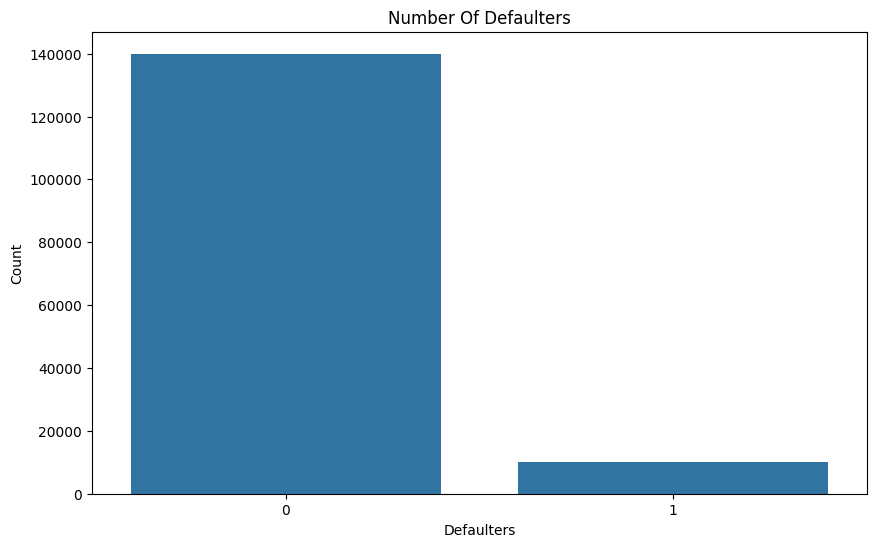

In [ ]:
# Let's see our Target Varibale as an individual column

plt.figure(figsize=(10,6))

sns.countplot(x = "SeriousDlqin2yrs", data = df)
plt.xlabel("Defaulters")
plt.ylabel("Count")
plt.title("Number Of Defaulters")
plt.show()

## This Graph represents the number of people who are defaulters and non-defaulters - 0 represtents the people who did not default and 1 represents the defaulters and count shows total no. of these people

## After taking a look at this graph we can see that the majority number of borrowers did not default and a very small portion of borrowers are defaulters(1). This means that the target
## variable is imblanced therefore the model will have more exaples for people who did default

## Since the dataset is imbalanced, accuracy alone is not a reliable evaluation metric.A model will have a high accuracy simply by predicting every borrower as a non-defaulter.

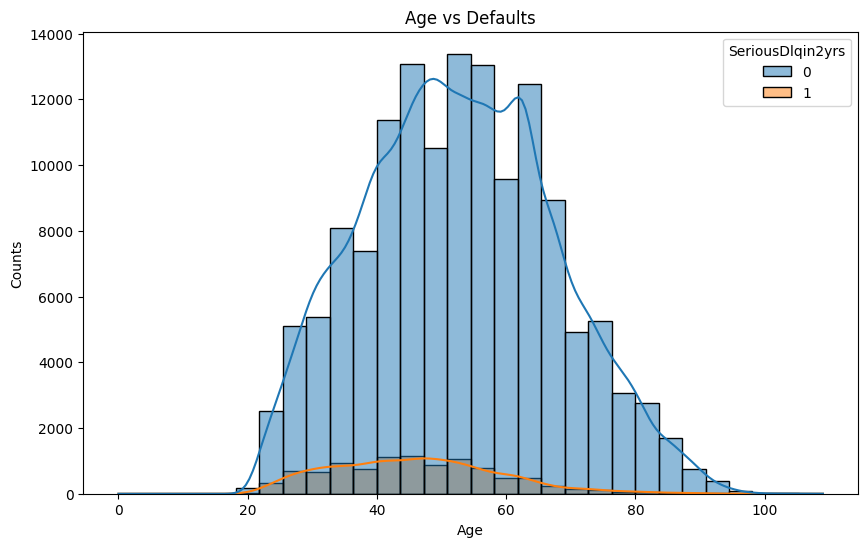

In [ ]:
# Let's Compare Age with Defaults on a Hist Plot
plt.figure(figsize=(10,6))

sns.histplot(
    x = "age",
    data = df,
    hue = "SeriousDlqin2yrs",
    bins = 30,
    kde = True
    )

plt.xlabel("Age")
plt.ylabel("Counts"),
plt.title("Age vs Defaults")
plt.show()

## This graph shows us the relation between the age of the borrower and the frequency of their defaults according to their age

## We can see that the Younger borrowers are more likely to default than the older borrowers between age 30-60

## Since Age shows us a relation of the borrowers unable to pay their debts it should be retained for the model training

In [ ]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


<Axes: xlabel='DebtRatio'>

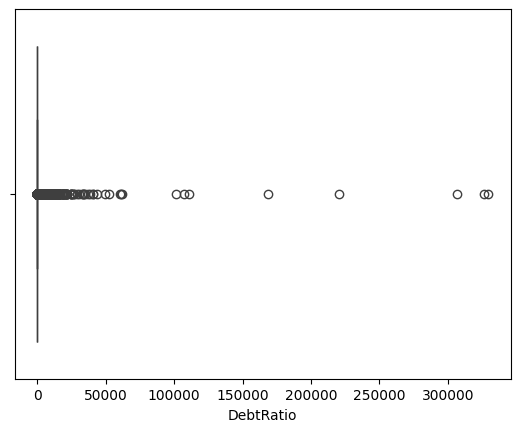

In [ ]:
sns.boxplot(x=df["DebtRatio"])

In [ ]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df["MonthlyIncome"].describe()

,MonthlyIncome
count,1.500000e+05
mean,6.418455e+03
std,1.289040e+04
min,0.000000e+00
25%,3.903000e+03
50%,5.400000e+03
75%,7.400000e+03
max,3.008750e+06


<Axes: xlabel='MonthlyIncome'>

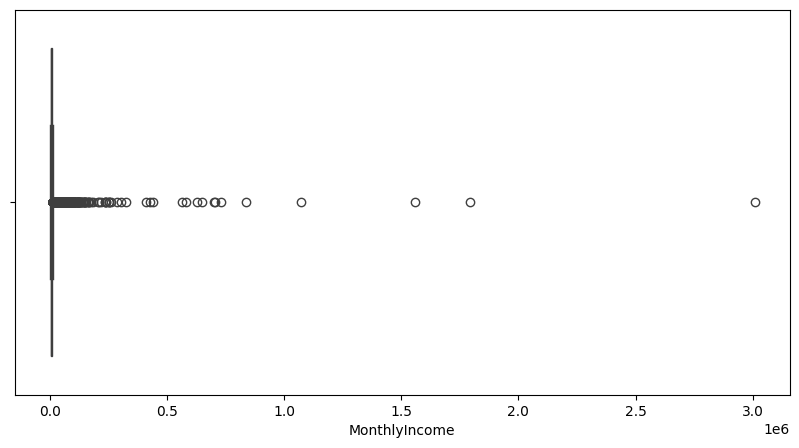

In [ ]:
# Let's Visualize it to find Outliers

plt.figure(figsize = (10,5))

sns.boxplot(x = df["MonthlyIncome"])

Text(0.5, 1.0, 'Monthly Income vs Defaults')

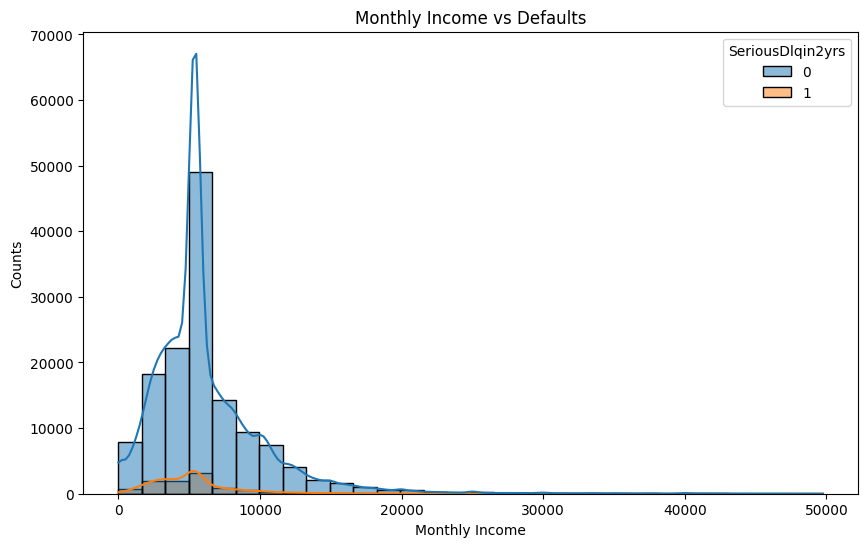

In [ ]:
# Let's compare Monthly Income using a HistPlot with Defaults

plt.figure(figsize = (10,6))

sns.histplot(
    x = "MonthlyIncome",
    data = df[df["MonthlyIncome"] < 50000],
    bins = 30,
    hue = "SeriousDlqin2yrs",
    kde = True
)

plt.xlabel("Monthly Income")
plt.ylabel("Counts")
plt.title("Monthly Income vs Defaults")

In [ ]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


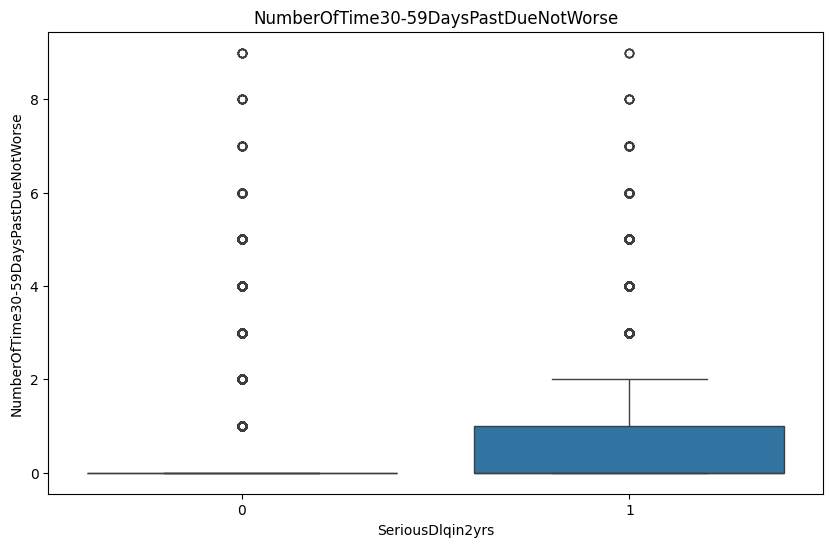

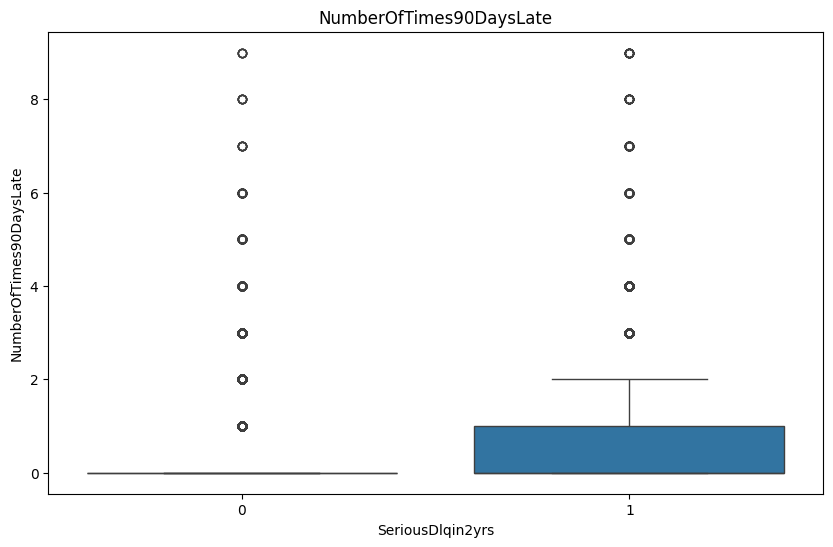

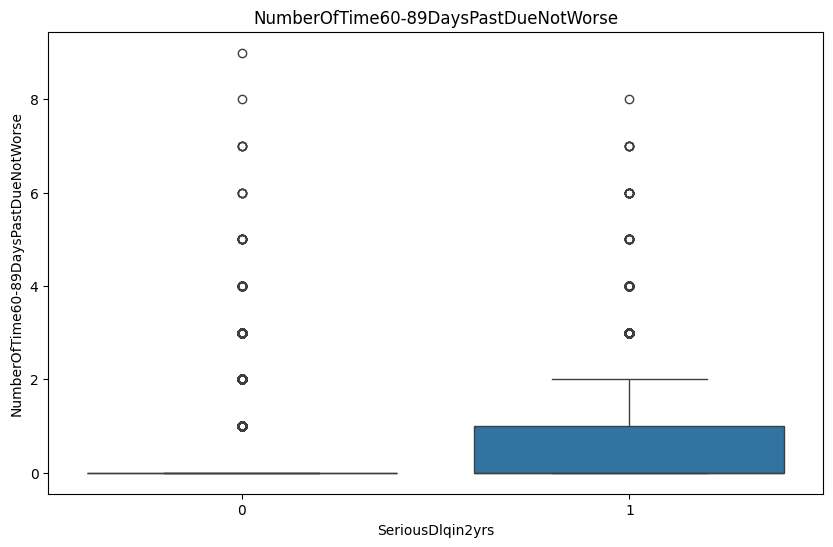

In [ ]:
# Let's Compare The Number of time a person dues in months eith the Target variable

cols = ["NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfTime60-89DaysPastDueNotWorse"]

for col in cols :
  plt.figure(figsize=(10,6))

  sns.boxplot(x = "SeriousDlqin2yrs", y=col, data = df[df[col] < 10])
  plt.title(col)
  plt.show()


In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


<Axes: xlabel='NumberOfOpenCreditLinesAndLoans'>

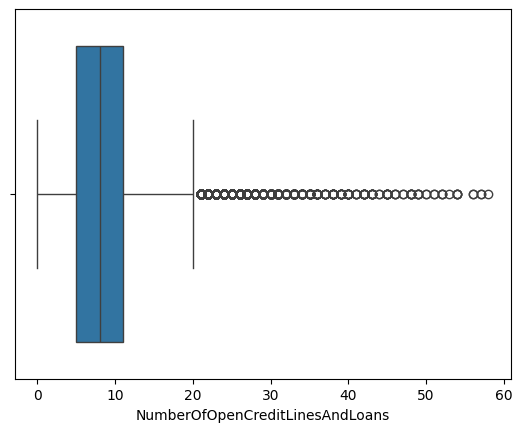

In [ ]:
# Let's check if number of Cresit Line Opened affect the No. of Defaults

sns.boxplot(x = df["NumberOfOpenCreditLinesAndLoans"])

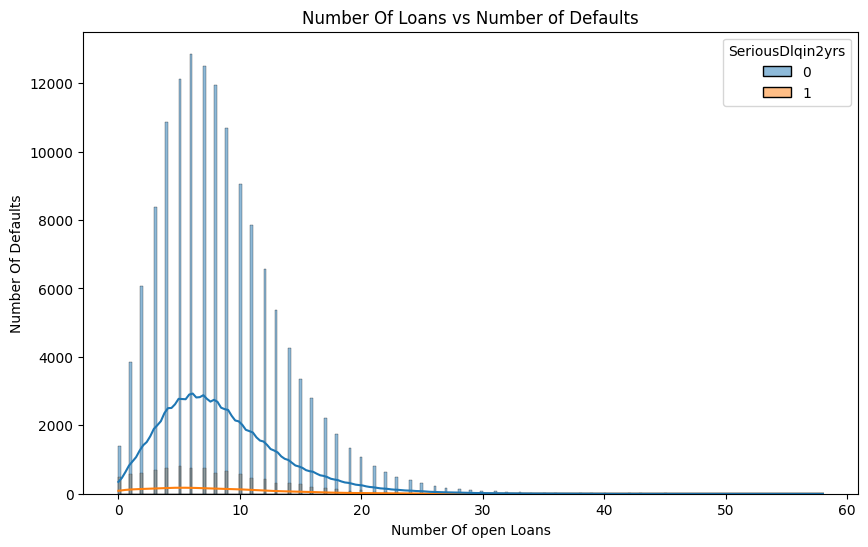

In [ ]:
# Let's compare it with the Number Of Defaults

plt.figure(figsize = (10,6))

sns.histplot(
    x = "NumberOfOpenCreditLinesAndLoans",
    data = df,
    hue = "SeriousDlqin2yrs",
    kde = True)

plt.xlabel("Number Of open Loans")
plt.ylabel("Number Of Defaults")
plt.title("Number Of Loans vs Number of Defaults")
plt.show()

In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


<Axes: xlabel='NumberOfDependents'>

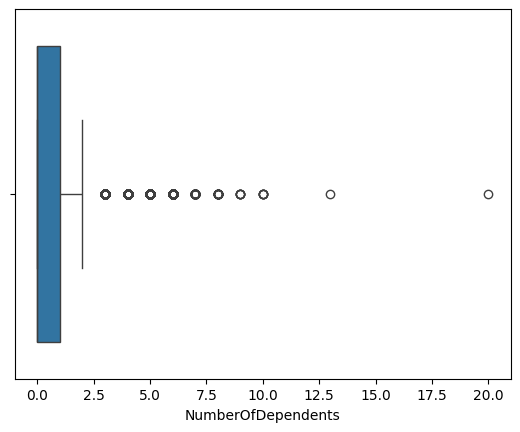

In [ ]:
# Let's Check if the number of Dependents have any affect on Number of Defaults

sns.boxplot(x = df["NumberOfDependents"])

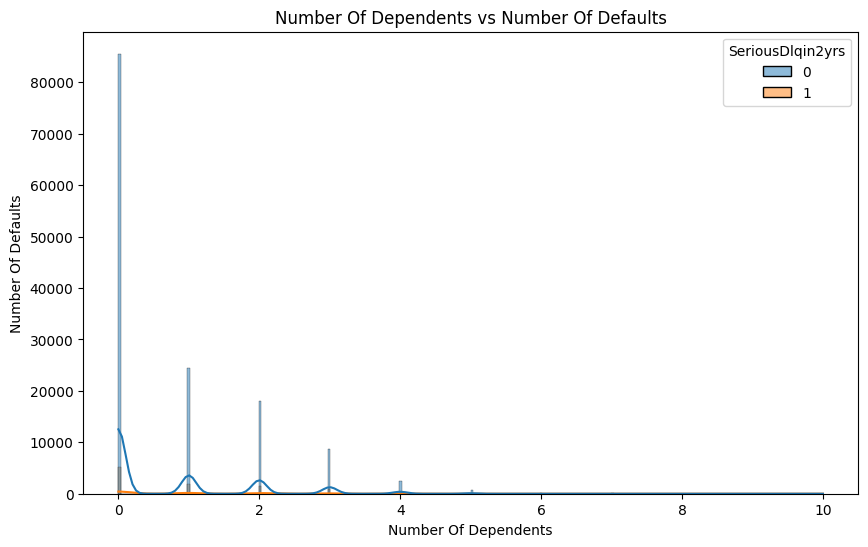

In [ ]:
# Let's Compare it

plt.figure(figsize=(10,6))

sns.histplot(
    x = "NumberOfDependents",
    data = df[df["NumberOfDependents"] <= 10],
    hue = "SeriousDlqin2yrs",
    kde = True)

plt.xlabel("Number Of Dependents")
plt.ylabel("Number Of Defaults")
plt.title("Number Of Dependents vs Number Of Defaults")
plt.show()


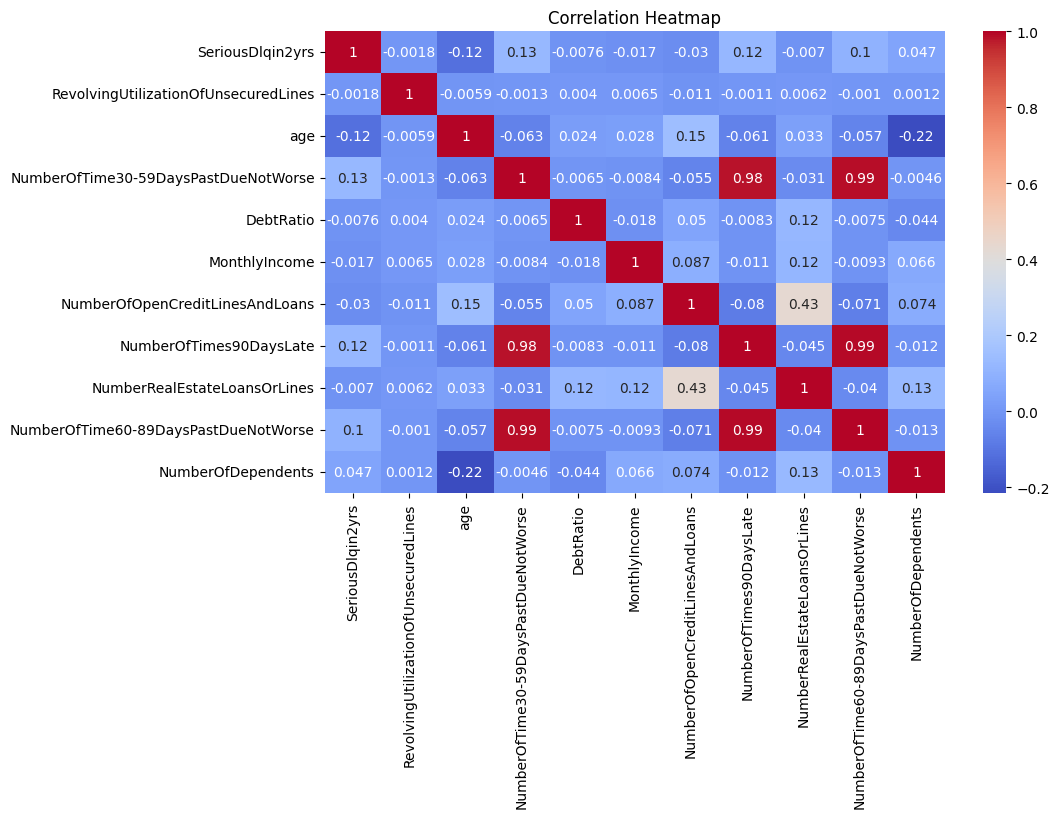

In [ ]:
## Let's create a heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
## We have analysed all the data and it's flows now let's fir this data into an XGBoost Model

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
## Let's make a function to fit the models and test their accuracy

import pandas as pd

models_dict = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "KNN": KNeighborsClassifier()
}


def test_and_score(models, X_train, X_test, y_train, y_test):
  final_dict = {}
  for model_name, model in models.items():
    model.fit(X_train, y_train)
    a = model.score(X_test, y_test)
    final_dict[model_name] = a*100

  return final_dict


df = pd.read_csv("cs-training.csv")
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(), inplace=True)

X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



final_dict = test_and_score(models_dict, X_train, X_test, y_train, y_test)

final_dict

/tmp/ipykernel_654/3403047241.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
/tmp/ipykernel_654/3403047241.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

{'Logistic Regression': 93.46666666666667,
 'Decision Tree': 89.8,
 'Random Forest': 93.76333333333334,
 'XGBoost': 93.70333333333333,
 'KNN': 93.15333333333334}

In [ ]:
df.duplicated().sum()

np.int64(0)

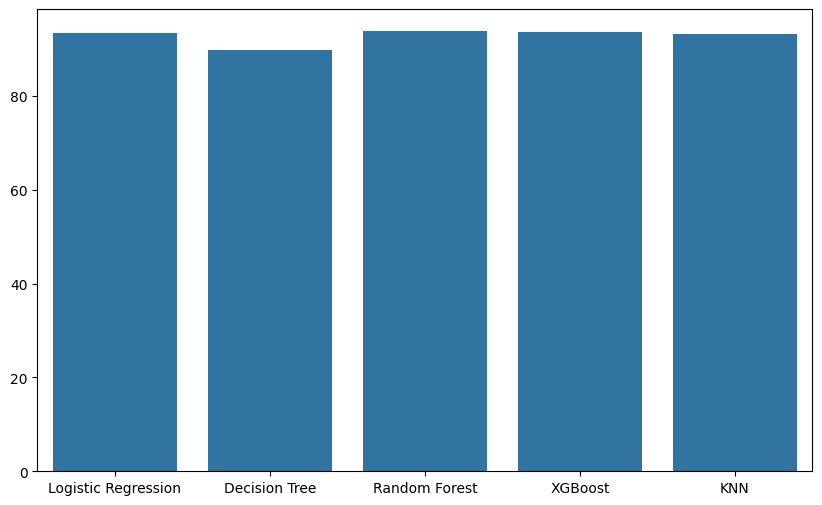

In [ ]:
plt.figure(figsize=(10,6))


sns.barplot(
    x = final_dict.keys(),
    y = final_dict.values(),
    data = final_dict
)
plt.show()

In [ ]:
## Let's try to change the parameters of these models and find if we can increase their accuracy

#Importing necessary libraries

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import time

## Creating a function to find the best parameters and scores for each model
def compare_and_best(X_train, y_train, estimators_and_params):
  best_params_and_scores = {}

  for estimator, params in estimators_and_params.items() :
    start_time = time.time()

    grid = RandomizedSearchCV(
        estimator=estimator,
        param_distributions = params,
        cv=3,
        n_iter=20,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1
        )

    grid.fit(X_train, y_train)
    best_params_and_scores[type(estimator).__name__] = {
        "Best Params": grid.best_params_,
        "Best Scores": grid.best_score_
    }
    end_time = time.time()
    print(f"It took a total of {end_time - start_time} seconds to train {type(estimator).__name__}")


  return  best_params_and_scores

## Setting up a random seed
np.random.seed(42)

# Creating the datasets to train and test the models that we modified
df = pd.read_csv("cs-training.csv")
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(),inplace=True)
df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(),inplace=True)

X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

estimator_and_params = {
    LogisticRegression(random_state=42, max_iter=1000): {
        "C":[0.001,0.01,0.1,1,10,100],
        "penalty":["l1","l2"],
        "solver":["liblinear"],
        "class_weight":[None, "balanced"]
        },
    DecisionTreeClassifier(random_state=42):{
        "max_depth": [3,5,10,15,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4],
        "criterion":["gini","entropy"]

    },
    RandomForestClassifier(random_state=42):{
        "n_estimators":[100,200,300],
        "max_depth":[10,20,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4],
        "max_features":["sqrt","log2"]

    },
    KNeighborsClassifier():{
        "n_neighbors":[3,5,7,9,11],
        "weights":["uniform","distance"],
        "metric":["euclidean", "manhattan"]
    },
    XGBClassifier(random_state=42):{
        "n_estimators":[100,200,300],
        "learning_rate":[0.01,0.1,0.05],
        "max_depth":[3,5,7],
        "subsample":[0.8,1.0],
        "colsample_bytree":[0.8,1.0]
    }
    }

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

final_scores = compare_and_best(X_train_scaled, y_train, estimator_and_params)





/tmp/ipykernel_654/2497136317.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(),inplace=True)
/tmp/ipykernel_654/2497136317.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

It took a total of 97.79981112480164 seconds to train LogisticRegression
It took a total of 41.602487564086914 seconds to train DecisionTreeClassifier


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
estimator = XGBClassifier(random_state=42)


params = {
        "n_estimators":[100,200,300],
        "learning_rate":[0.01,0.1,0.05],
        "max_depth":[3,5,7],
        "subsample":[0.8,1.0],
        "colsample_bytree":[0.8,1.0]
    }

grid = RandomizedSearchCV(
    XGBClassifier(random_state=42),
        param_distributions = params,
        cv=3,
        n_iter=20,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1


                          )

grid.fit(X_train, y_train)

grid.best_params_



{'subsample': 1.0,
 'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [ ]:
last_score = {}
for model in final_scores :
  last_score[model] = final_scores[model]["Best Scores"]*100

last_score

In [ ]:
## Let's plot all the Best Scores graphically

plt.figure(figsize=(10,6))

sns.barplot(
    x=last_score.keys(),
    y=last_score.values(),
    data=last_score
)
plt.show()


In [ ]:
## As we can see that the XGBClassifier managed to obtain the highest score out of them all therefore we will fit all the data into the XGBClassifier
## We will fit the model and evaluate the model using the best_params we got after running the RandomizedSearchCV

## Setup the random seed
np.random.seed(42)

## Import all the Libraries needed for evaluation
from xgboost import plot_importance
import joblib

df = pd.read_csv("cs-training.csv")

# Now Filling up all the Empty Blocks present in the respected columns and relacing them with the median of the rows
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(), inplace=True)

# Dividing the Dataset into labels and without labels
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

# Setting up the training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Setting up the XGBClassifier with the best params we recorded earlier

best_xgb = XGBClassifier(
  subsample = 1.0,
  n_estimators = 200,
  max_depth = 5,
  learning_rate = 0.05,
  colsample_bytree = 0.8,
  random_state=42
)

best_xgb.fit(X_train, y_train)

joblib.dump(best_xgb, "credit_default_model.pkl")
joblib.dump(scaler, "scaler.pkl")

/tmp/ipykernel_654/3425929287.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
/tmp/ipykernel_654/3425929287.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

['scaler.pkl']

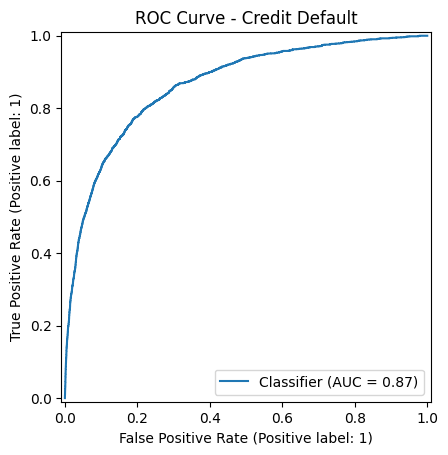

In [ ]:
# Plotting an ROC Curve

from sklearn.metrics import RocCurveDisplay
y_prob = best_xgb.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Credit Default")
plt.show()

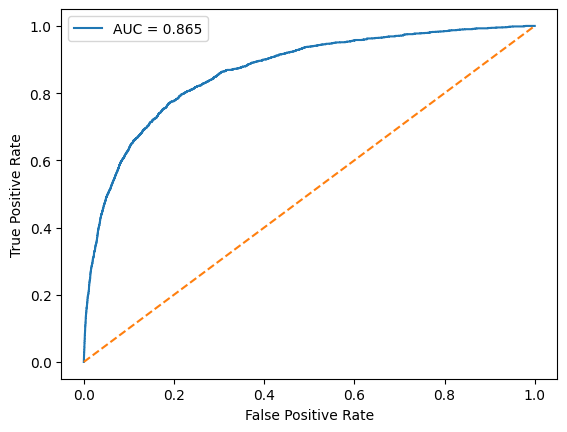

In [ ]:
## Let's see another variant for the ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

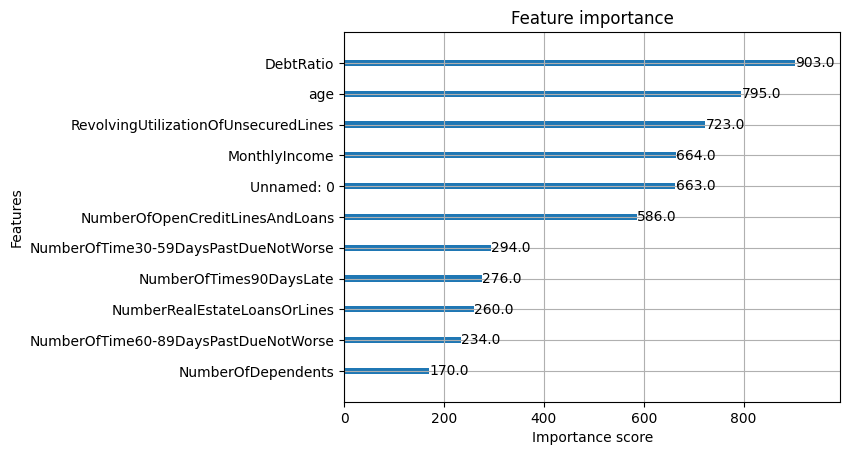

In [ ]:
# Let's CHeck Feature Importance
plot_importance(best_xgb)

In [7]:
## Let's Evaluate our model on the following libraries
import pandas as pd
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split
import joblib

## Load the model already availaible
model = joblib.load("credit_default_model.pkl")

## Create X_test and y_test
df = pd.read_csv("cs-training.csv")

X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_preds = model.predict(X_test)

accuracy = accuracy_score(y_test, y_preds)
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
roc_auc = roc_auc_score(y_test, y_preds)
classification_report = classification_report(y_test, y_preds)

/tmp/ipykernel_3553/4116450607.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


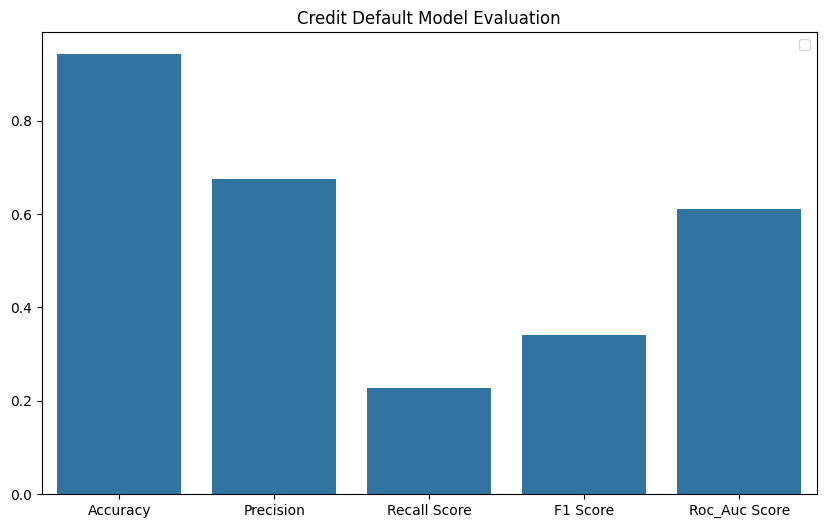

In [15]:
## Let's Visualize all the scores using a bar plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

Evaluation = {}

Evaluation["Accuracy"] = accuracy
Evaluation["Precision"] = precision
Evaluation["Recall Score"] = recall
Evaluation["F1 Score"] = f1
Evaluation["Roc_Auc Score"] = roc_auc


sns.barplot(
    x=Evaluation.keys(),
    y=Evaluation.values()
)
plt.title("Credit Default Model Evaluation")
plt.show()